# Plane Recognition from satelite imagery

In this project I will identify planes from satellite imagery, using various Deep Learning techniques.
With the growing availability of high-frequency satellite imagery, there is a critical need to automate object detection tasks such as airplane identification. These applications include: airport activity monitoring, air traffic pattern analysis, and defense intelligence gathering. Manual analysis at this scale is no longer feasible, and deep learning approaches offer a powerful, scalable solution.


## About the dataset

The PlanesNet dataset was extracted from Kaggle (https://www.kaggle.com/datasets/rhammell/planesnet).
The dataset consists of 32,000 RGB satellite images, each sized 20×20 pixels, collected by PlanetScope satellites over various airports in California. Each image is labeled as either containing an airplane (1) or not (0), with diverse examples in both categories. The “no-plane” class includes land features, partial planes, and challenging false-positive cases — making this a realistic and nuanced dataset for binary image classification.

The dataset is provided as a zipped folder containing:

A `planesnet/` directory with all `.png` image files

A `planesnet.json` file that stores the pixel data and metadata


Each image filename follows this format:
`{label}_{scene_id}_{longitude}_{latitude}.png`
Where:

`label`: `0` or `1` indicating the presence of a plane

`scene_id`: a unique ID for the original satellite scene

`longitude_latitude`: coordinates of the image center

## Exploratory Data Analysis (EDA)

In [1]:
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset_path = kagglehub.dataset_download("rhammell/planesnet")
img_dir = os.path.join(dataset_path, "planesnet", "planesnet")

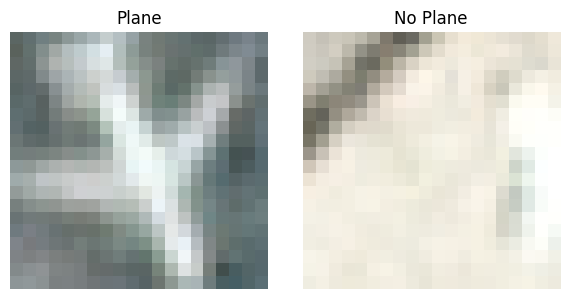

In [3]:
# Get all image filenames
image_filenames = os.listdir(img_dir)

# Separate plane and no-plane images based on filename prefix
plane_imgs = [f for f in image_filenames if f.startswith("1_")]
no_plane_imgs = [f for f in image_filenames if f.startswith("0_")]

# Sample one of each
sample_plane = np.random.choice(plane_imgs)
sample_no_plane = np.random.choice(no_plane_imgs)

# Load the images
img_plane = Image.open(os.path.join(img_dir, sample_plane))
img_no_plane = Image.open(os.path.join(img_dir, sample_no_plane))

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].imshow(img_plane)
axs[0].set_title("Plane")
axs[0].axis('off')

axs[1].imshow(img_no_plane)
axs[1].set_title("No Plane")
axs[1].axis('off')

plt.tight_layout()
plt.show()

Total number of images: 32000
Number of plane images: 8000
Number of no-plane images: 24000 

Image size: (20, 20)
Image mode: RGB


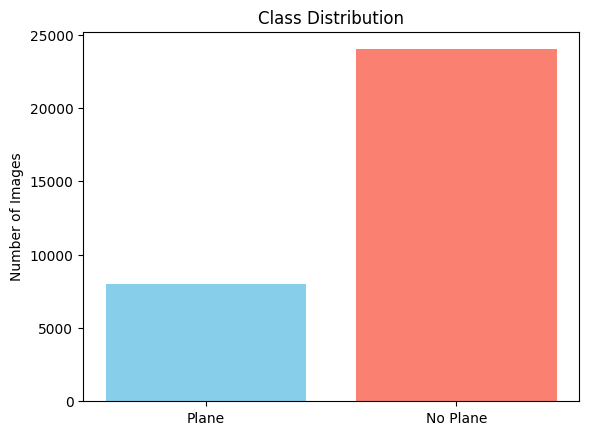

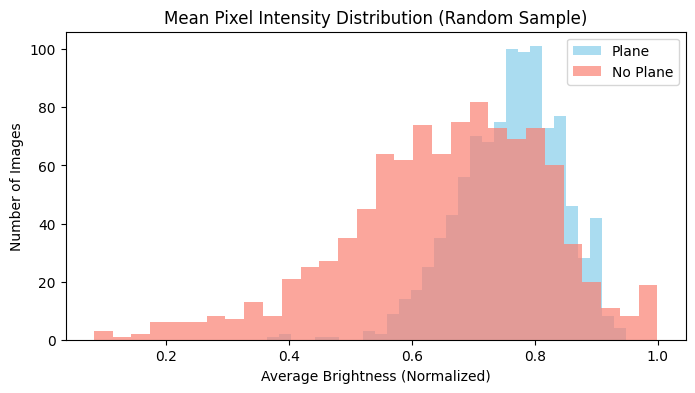

In [4]:
num_planes = len(plane_imgs)
num_no_planes = len(no_plane_imgs)

print(f"Total number of images: {len(image_filenames)}")
print(f"Number of plane images: {num_planes}")
print(f"Number of no-plane images: {num_no_planes} \n")

sample_img_path = os.path.join(img_dir, image_filenames[0])
sample_img = Image.open(sample_img_path)

# Get image dimensions
print(f"Image size: {sample_img.size}") 
print(f"Image mode: {sample_img.mode}") 


plt.bar(["Plane", "No Plane"], [num_planes, num_no_planes], color=["skyblue", "salmon"])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()


def compute_mean_intensities(file_list, sample_size=1000):
    sample_files = random.sample(file_list, sample_size)  # random, no repeat
    pixel_means = []
    for fname in sample_files:
        img = Image.open(os.path.join(img_dir, fname))
        img_arr = np.asarray(img) / 255.0  # normalize to [0, 1]
        pixel_means.append(img_arr.mean())
    return pixel_means

# Randomly sample 1000 from each class
plane_brightness = compute_mean_intensities(plane_imgs)
no_plane_brightness = compute_mean_intensities(no_plane_imgs)

# Plot histograms
plt.figure(figsize=(8, 4))
plt.hist(plane_brightness, bins=30, alpha=0.7, label="Plane", color="skyblue")
plt.hist(no_plane_brightness, bins=30, alpha=0.7, label="No Plane", color="salmon")
plt.title("Mean Pixel Intensity Distribution (Random Sample)")
plt.xlabel("Average Brightness (Normalized)")
plt.ylabel("Number of Images")
plt.legend()
plt.show()


In this EDA, we sampled a plane and non-plane image, double checked the amount of images and their shapes, and looked at the class distribution, as well as the average pixel intensity per class image.
From this analysis, we conclude that the dataset is imbalanced (1:3 plane to no-plane ratio), all images are consistently sized at 20×20 pixels with 3 color channels, and that plane images tend to be brighter and more visually consistent than no-plane images. This suggests that while brightness may help early classification, the model should be encouraged to learn deeper visual features to generalize well.


With planes underrepresented in the dataset, the main risk is that the model will bias toward the majority class and misclassify planes as no-planes, leading to false negatives that could be critical in real-world applications.

## Build Models
### Preprocess image data

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.utils import Sequence

In [6]:
# Extract image paths and labels
image_paths = [os.path.join(img_dir, fname) for fname in image_filenames]
labels = [int(fname[0]) for fname in image_filenames]

# Stratified train/test split
train_paths, test_paths, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Verify distributions of classes with diagnostic prints
# Compute counts
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

# Compute ratios
train_ratios = train_counts / train_counts.sum()
test_ratios = test_counts / test_counts.sum()

print("Split diagnostics")
print("-------------------------------------------------------------")
print(f"Total images         : {len(image_paths)}")
print(f"Training images      : {len(train_paths)}")
print(f"Test images          : {len(test_paths)} \n")

print(f"Train class dist     : {train_counts} (0: no-plane, 1: plane)")
print(f"Train class ratios   : {train_ratios[0]:.2%} no-plane, {train_ratios[1]:.2%} plane \n")

print(f"Test class dist      : {test_counts} (0: no-plane, 1: plane)")
print(f"Test class ratios    : {test_ratios[0]:.2%} no-plane, {test_ratios[1]:.2%} plane \n \n")



# Define generator
class ImagePathGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size=32, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_paths = self.image_paths[index * self.batch_size:(index + 1) * self.batch_size]
        batch_labels = self.labels[index * self.batch_size:(index + 1) * self.batch_size]

        batch_images = []
        for path in batch_paths:
            img = Image.open(path).convert("RGB")
            img = img.resize((20, 20))  # Ensure consistent size
            img_arr = np.asarray(img) / 255.0  # Normalize
            batch_images.append(img_arr)

        return np.array(batch_images), np.array(batch_labels)

    def on_epoch_end(self):
        if self.shuffle:
            temp = list(zip(self.image_paths, self.labels))
            np.random.shuffle(temp)
            self.image_paths, self.labels = zip(*temp)

# Initialize generators
batch_size = 32
train_gen = ImagePathGenerator(train_paths, y_train, batch_size=batch_size, shuffle=True)
test_gen = ImagePathGenerator(test_paths, y_test, batch_size=batch_size, shuffle=False)

# Class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

print("Class Weights (to handle imbalance)")
print("-------------------------------------------------------------")
print(f"Class 0 (no-plane): {class_weights_dict[0]:.2f}")
print(f"Class 1 (plane)   : {class_weights_dict[1]:.2f}")

Split diagnostics
-------------------------------------------------------------
Total images         : 32000
Training images      : 25600
Test images          : 6400 

Train class dist     : [19200  6400] (0: no-plane, 1: plane)
Train class ratios   : 75.00% no-plane, 25.00% plane 

Test class dist      : [4800 1600] (0: no-plane, 1: plane)
Test class ratios    : 75.00% no-plane, 25.00% plane 
 

Class Weights (to handle imbalance)
-------------------------------------------------------------
Class 0 (no-plane): 0.67
Class 1 (plane)   : 2.00


### Model 1 (Baseline CNN)

In [7]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(20, 20, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    class_weight=class_weights_dict
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6416 - loss: 0.5310 - val_accuracy: 0.8808 - val_loss: 0.2696
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8974 - loss: 0.2413 - val_accuracy: 0.8956 - val_loss: 0.2429
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9172 - loss: 0.1991 - val_accuracy: 0.9303 - val_loss: 0.1716
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9343 - loss: 0.1606 - val_accuracy: 0.9583 - val_loss: 0.1198
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9398 - loss: 0.1482 - val_accuracy: 0.9561 - val_loss: 0.1220
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9423 - loss: 0.1428 - val_accuracy: 0.9597 - val_loss: 0.1107
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9432 - loss: 0.1383 - val_accuracy: 0.9681 - val_loss: 0.0908
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9484 - loss: 0.1295 - val_accuracy: 0.

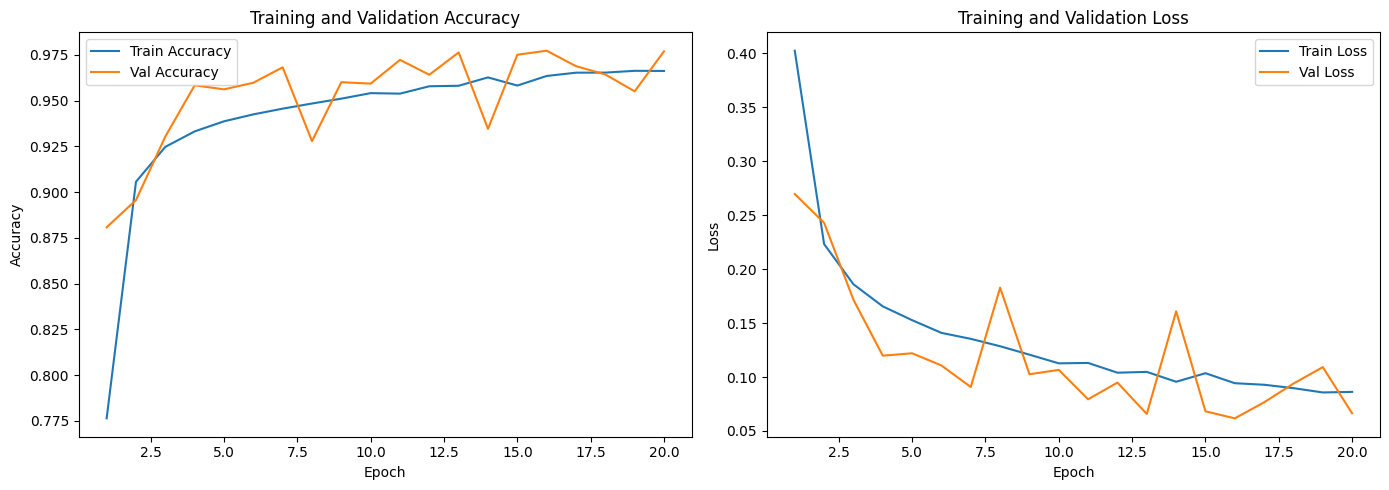

Classification Report:
              precision    recall  f1-score   support

    No Plane       0.99      0.98      0.98      4800
       Plane       0.94      0.97      0.95      1600

    accuracy                           0.98      6400
   macro avg       0.96      0.98      0.97      6400
weighted avg       0.98      0.98      0.98      6400



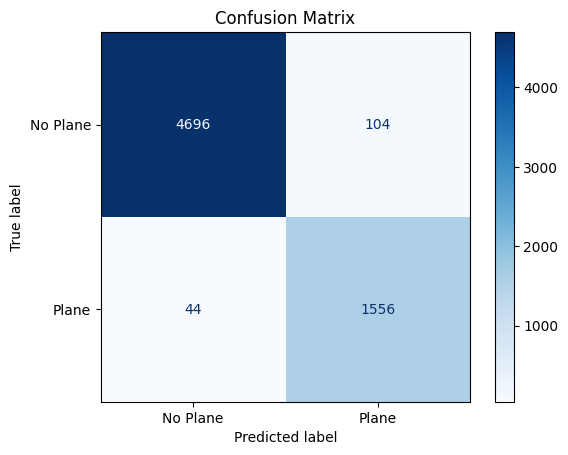

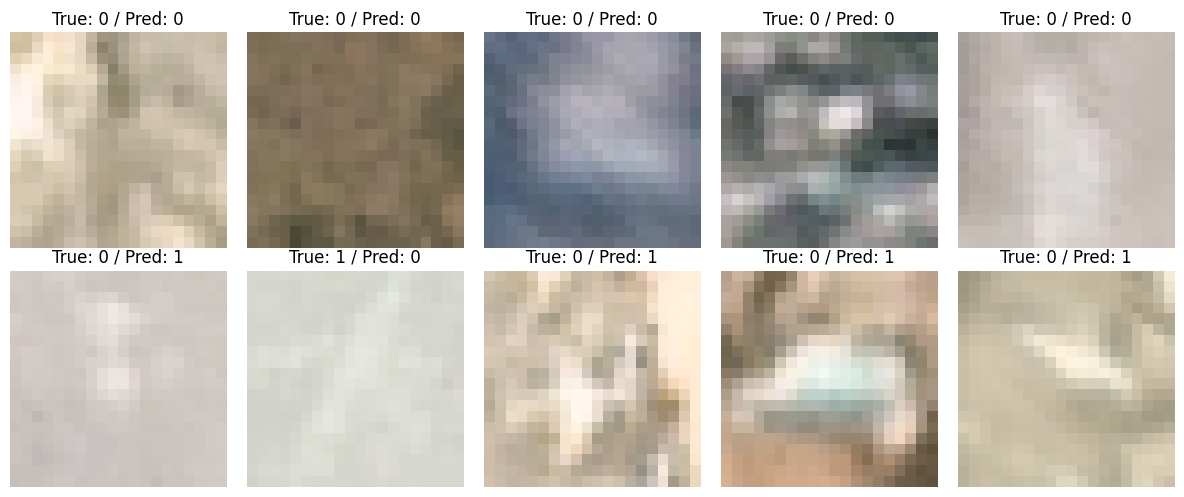

In [9]:
def plot_training_history(history, save=True, model_name="baseline"):
    history = history.history
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    if save:
        plt.savefig(f"Figures/train_val_loss_{model_name}.png", dpi=200)
    plt.show()
    
    
def get_predictions(model, generator, total_samples):
    y_true = []
    y_pred = []
    images = []

    for X_batch, y_batch in generator:
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(y_batch)
        y_pred.extend((preds > 0.5).astype(int).flatten())
        images.extend(X_batch)

        # Stop when we've seen all test samples
        if len(y_true) >= total_samples:
            break

    return np.array(y_true), np.array(y_pred), np.array(images)

def plot_confusion(y_true, y_pred, save=True, model_name="baseline"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Plane', 'Plane'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    if save:
        plt.savefig(f"Figures/cm_planes_{model_name}.png", dpi=200)
    plt.show()
    
    
def visualize_predictions(images, y_true, y_pred, num=5):
    correct_idxs = np.where(y_true == y_pred)[0][:num]
    incorrect_idxs = np.where(y_true != y_pred)[0][:num]

    plt.figure(figsize=(12, 5))

    for i, idx in enumerate(correct_idxs):
        plt.subplot(2, num, i + 1)
        plt.imshow(images[idx])
        plt.title(f"True: {y_true[idx]} / Pred: {y_pred[idx]}")
        plt.axis('off')

    for i, idx in enumerate(incorrect_idxs):
        plt.subplot(2, num, num + i + 1)
        plt.imshow(images[idx])
        plt.title(f"True: {y_true[idx]} / Pred: {y_pred[idx]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


plot_training_history(history)

y_true, y_pred, test_images = get_predictions(model, test_gen, total_samples=len(y_test))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Plane", "Plane"]))

plot_confusion(y_true, y_pred)
visualize_predictions(test_images, y_true, y_pred, num=5)

### Remarks Model 1
After training for 15 epochs, the model achieved a high peak validation accuracy of ~ 97%. The accuracy and loss plots show continuous improvement, and no over or underfitting. More importantly, out of 1,600 actual planes in the test set, the model correctly identified 1556, missing only 44 — demonstrating a recall of 97% for the "plane" class.

In this context, recall is critical, as the primary goal is to ensure no planes go undetected. A missed plane (false negative) could represent a serious failure in applications such as airport monitoring, defense, or surveillance. This high recall indicates the model is well-suited for real-world use where sensitivity to true positives is more important than avoiding false alarms.

### Model 2 (Baseline CNN without dropout)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7696 - loss: 0.4433 - val_accuracy: 0.9542 - val_loss: 0.1297
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9320 - loss: 0.1670 - val_accuracy: 0.9584 - val_loss: 0.1152
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9423 - loss: 0.1408 - val_accuracy: 0.9513 - val_loss: 0.1260
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9550 - loss: 0.1136 - val_accuracy: 0.9645 - val_loss: 0.0969
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9594 - loss: 0.1075 - val_accuracy: 0.9664 - val_loss: 0.0951
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9582 - loss: 0.1100 - val_accuracy: 0.9733 - val_loss: 0.0806
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9664 - loss: 0.0861 - val_accuracy: 0.9716 - val_loss: 0.0777
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9630 - loss: 0.0911 - val_accuracy: 0.

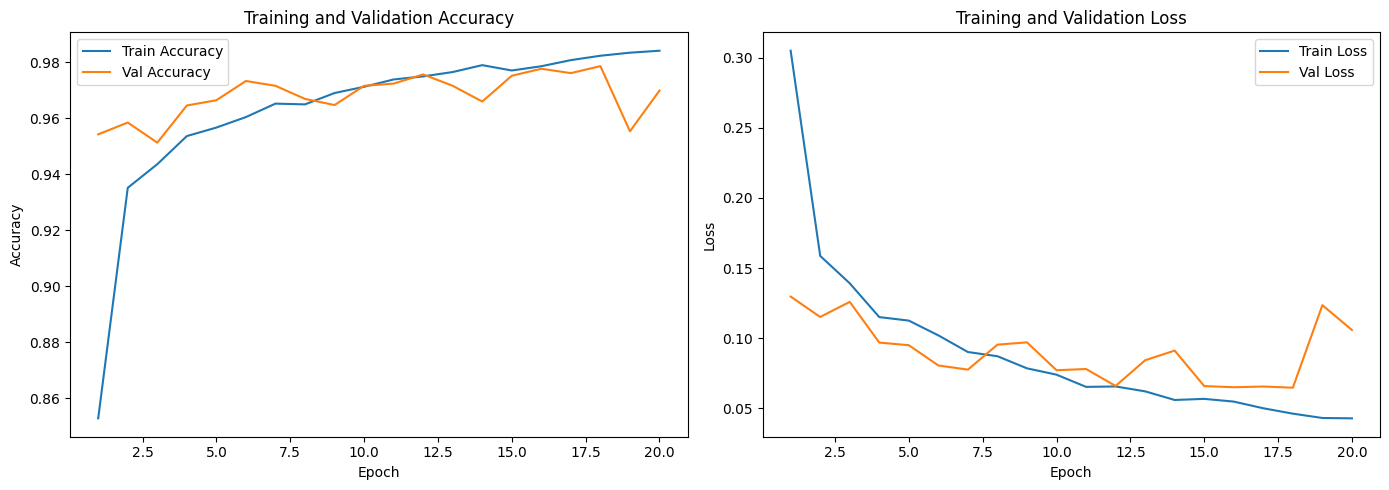

Classification Report:
              precision    recall  f1-score   support

    No Plane       0.97      0.99      0.98      4800
       Plane       0.97      0.90      0.94      1600

    accuracy                           0.97      6400
   macro avg       0.97      0.95      0.96      6400
weighted avg       0.97      0.97      0.97      6400



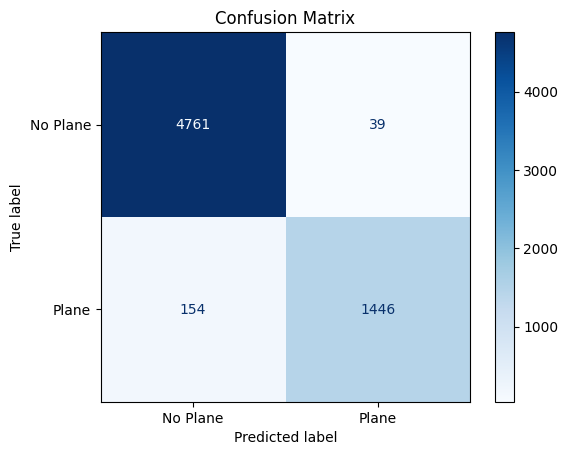

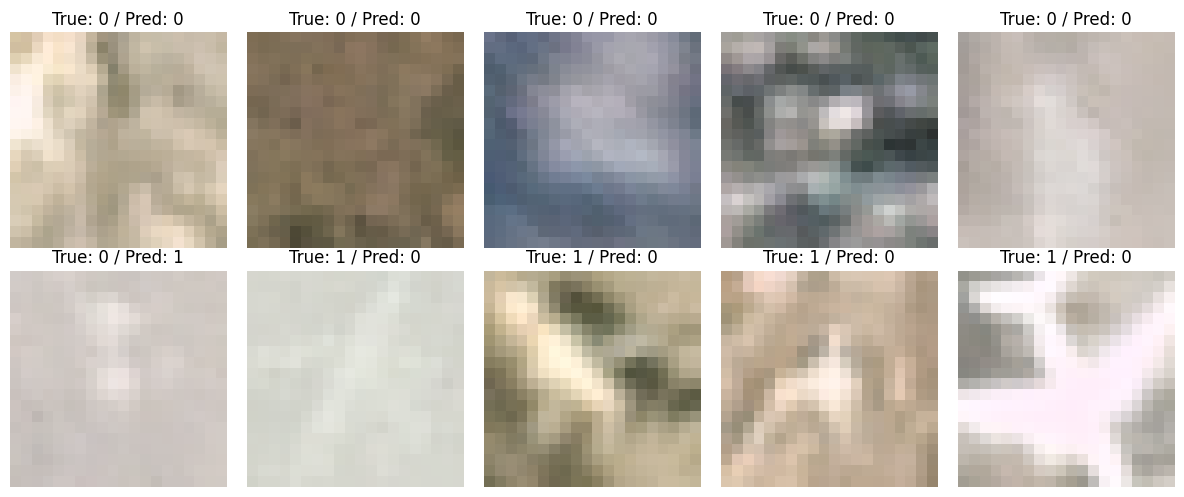

In [10]:
model_2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(20, 20, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


# Compile the model
model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model_2.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    class_weight=class_weights_dict
)


# Evaluate
plot_training_history(history, model_name='model_2')

y_true, y_pred, test_images = get_predictions(model_2, test_gen, total_samples=len(y_test))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Plane", "Plane"]))

plot_confusion(y_true, y_pred)
visualize_predictions(test_images, y_true, y_pred, num=5)

### Remarks Model 2

Interestingly, removing dropout from the baseline CNN improved performance. The model achieved a staggering peak validation accuracy of ~ 98%. This suggests that dropout, while typically helpful for generalization, may have hindered performance on this small, low-resolution dataset. The simplified architecture seems to be an advantage here and allowed the model to fully utilize its limited capacity to learn relevant patterns without overfitting. At the same time we see a lower recall, meaning that we missed detecting more real planes, which is problematic.


While visually inspecting incorrect predictions (bottom row), a clear plane in image 5 (bottom row) was identified as "not a plane", essentially slipping through our radar. This may be due to the image having only the partial aircraft visible (e.g., the nose cropped out). This suggests the model has learned to associate full-plane geometry with the target class. To improve robustness, future work could introduce more partial-plane training examples, to try and improve our recall. Since I don't have that right now, I can try to generate partial planes, by zooming-in on some existing plane images.

### Idea, to counter partial plane identification problem
Augment current dataset with zoomed-in images of planes, and retrain model 2.

### Model 2b (Model 2 with partial plane augmentation)

Epoch 1/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6714 - loss: 0.5054 - val_accuracy: 0.9389 - val_loss: 0.1690
Epoch 2/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8994 - loss: 0.2612 - val_accuracy: 0.9281 - val_loss: 0.1992
Epoch 3/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9162 - loss: 0.2222 - val_accuracy: 0.8973 - val_loss: 0.2553
Epoch 4/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9148 - loss: 0.2110 - val_accuracy: 0.9453 - val_loss: 0.1537
Epoch 5/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9314 - loss: 0.1838 - val_accuracy: 0.9267 - val_loss: 0.1901
Epoch 6/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9358 - loss: 0.1705 - val_accuracy: 0.9294 - val_loss: 0.1834
Epoch 7/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9407 - loss: 0.1543 - val_accuracy: 0.9645 - val_loss: 0.1005
Epoch 8/20
832/832 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9417 - loss: 0.1509 - 

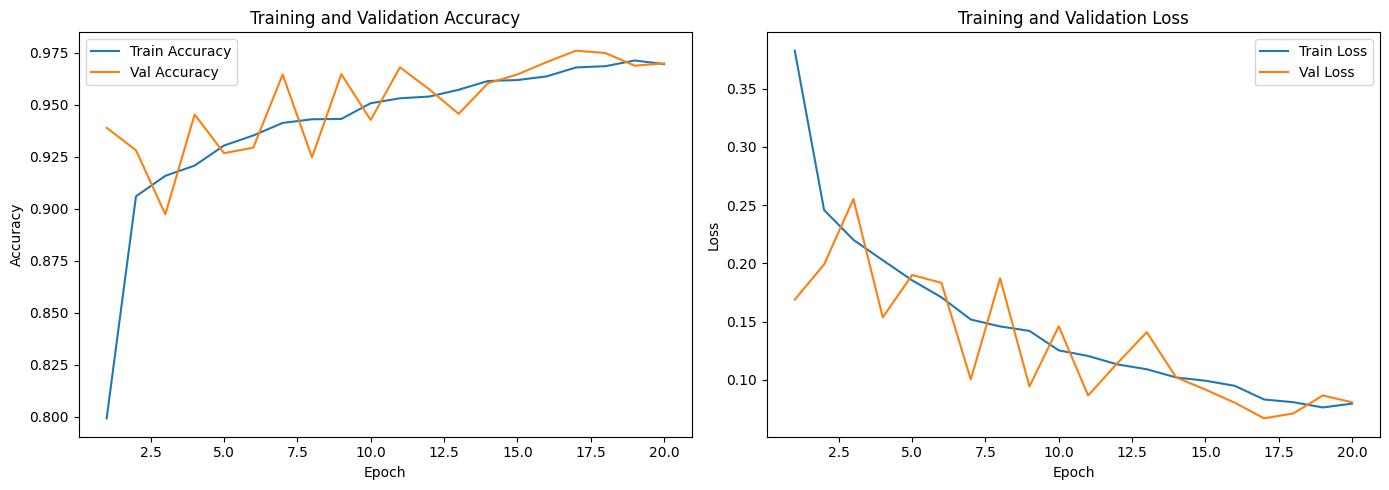

Classification Report:
              precision    recall  f1-score   support

    No Plane       0.99      0.97      0.98      4800
       Plane       0.91      0.98      0.94      1600

    accuracy                           0.97      6400
   macro avg       0.95      0.97      0.96      6400
weighted avg       0.97      0.97      0.97      6400



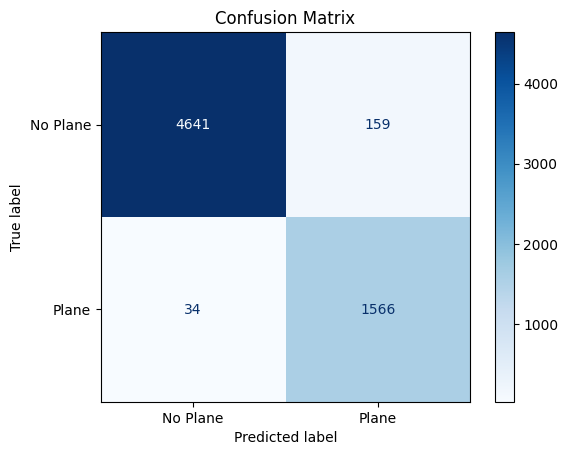

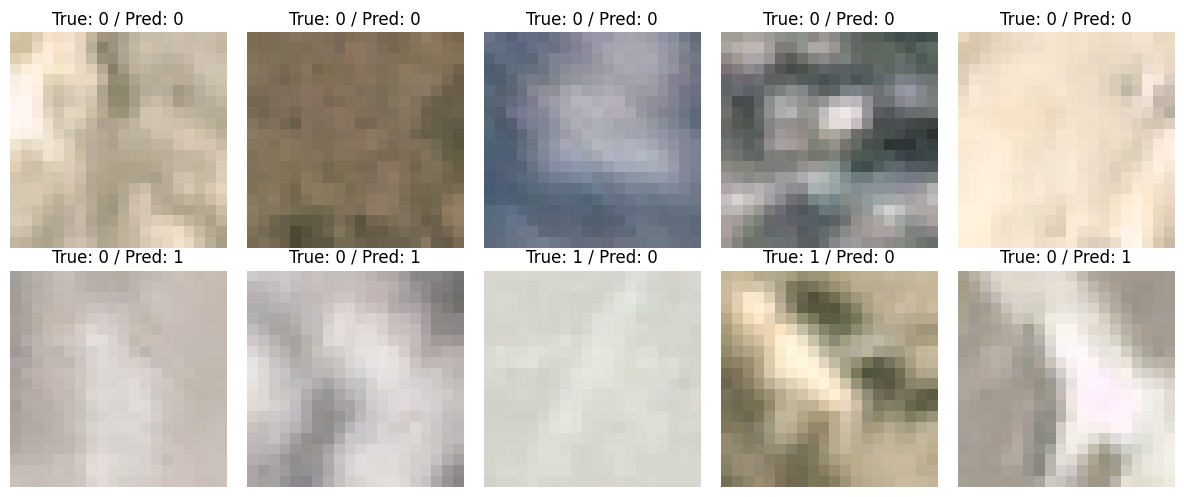

In [11]:
def generate_partial_planes(plane_paths, num_samples, zoom_range=(0.6, 0.9)):
    partial_images = []
    labels = []

    selected = random.sample(plane_paths, num_samples)

    for path in selected:
        img = Image.open(path).convert("RGB")
        img_np = np.array(img)
        h, w = img_np.shape[:2]

        scale = random.uniform(*zoom_range)
        new_h, new_w = int(h * scale), int(w * scale)

        x = random.randint(0, h - new_h)
        y = random.randint(0, w - new_w)

        cropped = img_np[x:x+new_h, y:y+new_w]
        resized = Image.fromarray(cropped).resize((20, 20))

        partial_images.append(np.array(resized) / 255.0)
        labels.append(1)  # Still label as "plane"

    return partial_images, labels

# Get full paths to plane-only training images
train_plane_paths = [p for p, y in zip(train_paths, y_train) if y == 1]

# Generate 1000 partial plane images
partial_imgs, partial_labels = generate_partial_planes(train_plane_paths, num_samples=1000)

# Extend training data
aug_train_paths = train_paths.copy()
aug_train_labels = y_train.copy()



class MixedImageGenerator(Sequence):
    def __init__(self, file_paths, file_labels, in_memory_images, in_memory_labels, batch_size=32, shuffle=True):
        self.file_paths = file_paths
        self.file_labels = file_labels
        self.in_memory_images = in_memory_images
        self.in_memory_labels = in_memory_labels
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil((len(self.file_paths) + len(self.in_memory_images)) / self.batch_size))

    def __getitem__(self, idx):
        combined = list(zip(self.file_paths, self.file_labels)) + list(zip(self.in_memory_images, self.in_memory_labels))
        if self.shuffle:
            random.shuffle(combined)

        batch = combined[idx * self.batch_size:(idx + 1) * self.batch_size]

        images = []
        labels = []

        for item in batch:
            if isinstance(item[0], str):
                img = Image.open(item[0]).convert("RGB").resize((20, 20))
                img = np.array(img) / 255.0
            else:
                img = item[0]
            images.append(img)
            labels.append(item[1])

        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        pass
    

model_2b = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(20, 20, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_2b.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Create the new generator with partial planes included
train_gen_2 = MixedImageGenerator(train_paths, y_train, partial_imgs, partial_labels, batch_size=32)
test_gen = ImagePathGenerator(test_paths, y_test, batch_size=32, shuffle=False)

history_2 = model_2b.fit(
    train_gen_2,
    validation_data=test_gen,
    epochs=20,
    class_weight=class_weights_dict
)

# Evaluate
plot_training_history(history_2, model_name='model_2b')

y_true, y_pred, test_images = get_predictions(model_2b, test_gen, total_samples=len(y_test))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Plane", "Plane"]))

plot_confusion(y_true, y_pred)
visualize_predictions(test_images, y_true, y_pred, num=5)

### Partial plane augmentation remarks
By introducing a set of synthetic “partial plane” images (generated by zooming and cropping real plane images),  the model's ability to detect planes — even when they are partially visible, significantly improved. This confirms that partial planes were indeed an important factor into misclassifying true planes. This augmented model led to a higher recall ofor the plane class, at the cost of precision, which dropped significantly. In absolute numbers, 34 planes 'slipped through the radar' compared to a previous 154 (model 2), whereas 159 non-planes are misclassified compared to a previous 39. In high-sensitivity applications, this is an acceptable trade-off: the model is now much less likely to miss a plane, even at the cost of occasionally misclassifying terrain.

### Model 3 (Pre-trained MobileNetV2 with tranfer learning)

Epoch 1/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - accuracy: 0.8250 - loss: 0.3588 - val_accuracy: 0.9306 - val_loss: 0.1758
Epoch 2/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.9102 - loss: 0.2121 - val_accuracy: 0.8913 - val_loss: 0.2479
Epoch 3/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 51s 64ms/step - accuracy: 0.9195 - loss: 0.1851 - val_accuracy: 0.9391 - val_loss: 0.1427
Epoch 4/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 53s 66ms/step - accuracy: 0.9314 - loss: 0.1583 - val_accuracy: 0.9528 - val_loss: 0.1239
Epoch 5/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.9381 - loss: 0.1476 - val_accuracy: 0.9527 - val_loss: 0.1242
Epoch 6/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 53s 66ms/step - accuracy: 0.9400 - loss: 0.1457 - val_accuracy: 0.9175 - val_loss: 0.1988
Epoch 7/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 51s 64ms/step - accuracy: 0.9430 - loss: 0.1331 - val_accuracy: 0.9528 - val_loss: 0.1164
Epoch 8/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.9416 - loss: 0.1383 - 

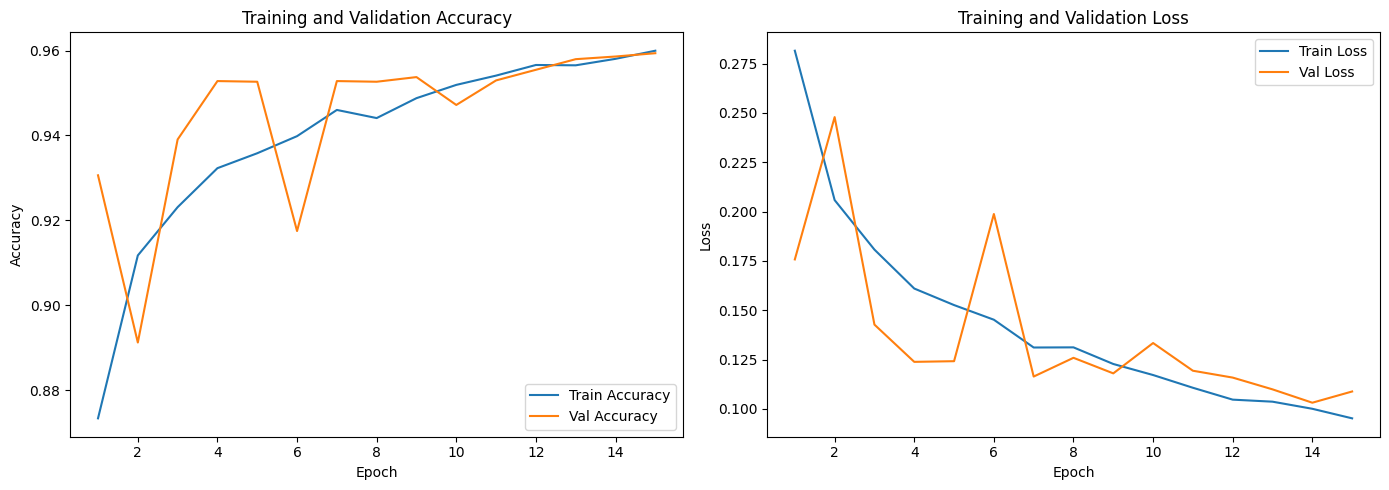

Classification Report:
              precision    recall  f1-score   support

    No Plane       0.97      0.98      0.97      4800
       Plane       0.93      0.90      0.92      1600

    accuracy                           0.96      6400
   macro avg       0.95      0.94      0.95      6400
weighted avg       0.96      0.96      0.96      6400



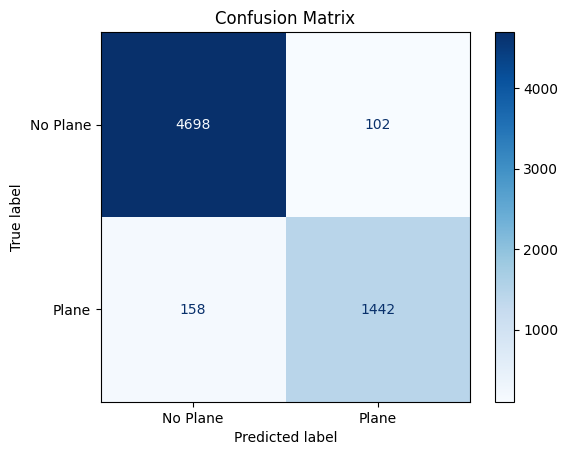

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17647058..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6..0.18431377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4588235..0.54509807].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6627451..0.8980392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5686275..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027450979..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32549018..1.0].


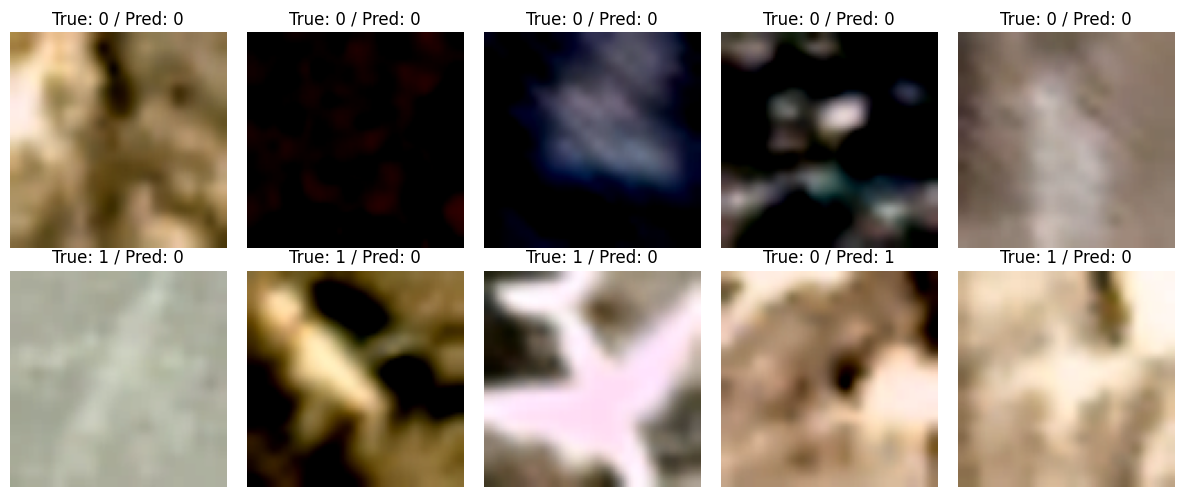

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


IMG_SIZE = 96  # Resize 20x20 → 96x96

# Modify generator to resize and preprocess for MobileNetV2
class PretrainedImageGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size=32, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_paths = self.image_paths[index * self.batch_size:(index + 1) * self.batch_size]
        batch_labels = self.labels[index * self.batch_size:(index + 1) * self.batch_size]

        batch_images = []
        for path in batch_paths:
            img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            img_arr = np.asarray(img)
            img_arr = preprocess_input(img_arr)  # MobileNet-specific preprocessing
            batch_images.append(img_arr)

        return np.array(batch_images), np.array(batch_labels)

    def on_epoch_end(self):
        if self.shuffle:
            combined = list(zip(self.image_paths, self.labels))
            random.shuffle(combined)
            self.image_paths, self.labels = zip(*combined)

# Initialize pretrained model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze all pretrained layers

# Tranfer learning
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_3 = Model(inputs=base_model.input, outputs=output)

model_3.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

train_gen_3 = PretrainedImageGenerator(train_paths, y_train)
test_gen_3 = PretrainedImageGenerator(test_paths, y_test, shuffle=False)

history_3 = model_3.fit(
    train_gen_3,
    validation_data=test_gen_3,
    epochs=15,
    class_weight=class_weights_dict
)


# Evaluate
plot_training_history(history_3, model_name='model_3')

y_true, y_pred, test_images = get_predictions(model_3, test_gen_3, total_samples=len(y_test))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Plane", "Plane"]))

plot_confusion(y_true, y_pred, model_name="model_3")
visualize_predictions(test_images, y_true, y_pred, num=5)

### Remarks Model 3
The third model used transfer learning with MobileNetV2 (a compact CNN pretrained on ImageNet). As expected this pretrained model has a high initial accuracy (at epoch 1), compared to the other models. Though it still keeps increasing a lot of epochs, and it takes a longer time to run an epoch (~50 sec). Running this portion of the code multiple times also shows high variability in the results. These results suggest that MobileNetV2 is highly sensitive to visual features even in upscaled low-res satellite imagery (which is backed up by the bouncing validation accuracy). Therefore the other models are more preferable.


Another thing worth noting that you can see in the images, is that we missed a partial plane. Idea: augment generated images with zoomed-in and cropped versions i.e. "partial planes", to try and further detect planes, like we did before.

### Model 3b (Model 3 with partial plane augmentation)

Epoch 1/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.8084 - loss: 0.3847 - val_accuracy: 0.8709 - val_loss: 0.2926
Epoch 2/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - accuracy: 0.9016 - loss: 0.2262 - val_accuracy: 0.9278 - val_loss: 0.1731
Epoch 3/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - accuracy: 0.9209 - loss: 0.1855 - val_accuracy: 0.9320 - val_loss: 0.1735
Epoch 4/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - accuracy: 0.9263 - loss: 0.1743 - val_accuracy: 0.9291 - val_loss: 0.1731
Epoch 5/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9343 - loss: 0.1550 - val_accuracy: 0.9283 - val_loss: 0.1774
Epoch 6/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - accuracy: 0.9383 - loss: 0.1466 - val_accuracy: 0.9478 - val_loss: 0.1384
Epoch 7/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - accuracy: 0.9392 - loss: 0.1431 - val_accuracy: 0.9563 - val_loss: 0.1145
Epoch 8/15
832/832 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9495 - loss: 0.1243 - 

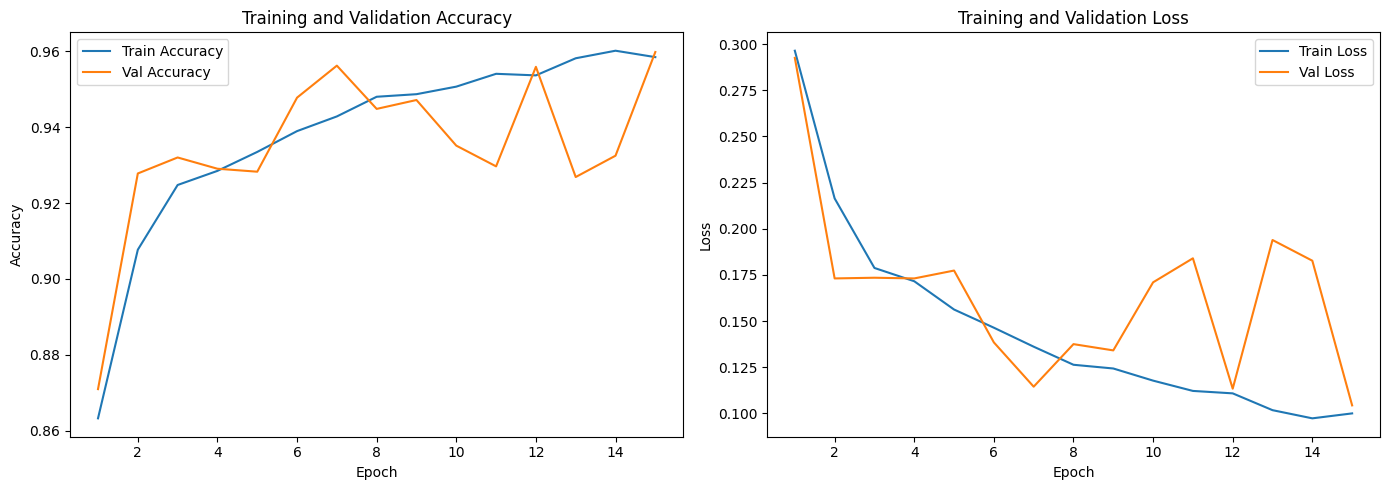

Classification Report:
              precision    recall  f1-score   support

    No Plane       0.98      0.96      0.97      4800
       Plane       0.89      0.95      0.92      1600

    accuracy                           0.96      6400
   macro avg       0.94      0.96      0.95      6400
weighted avg       0.96      0.96      0.96      6400



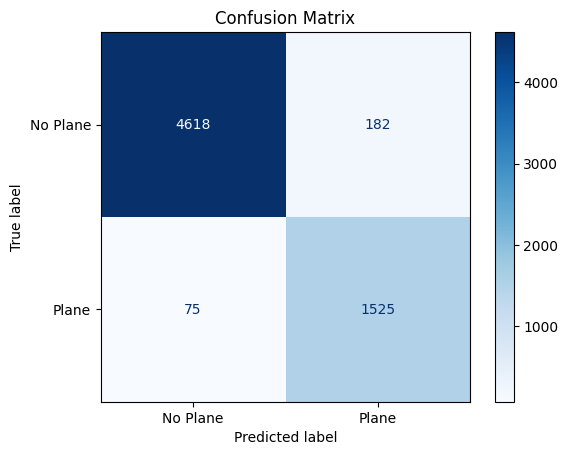

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17647058..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6..0.18431377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4588235..0.54509807].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6627451..0.8980392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5686275..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027450979..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027450979..1.0].


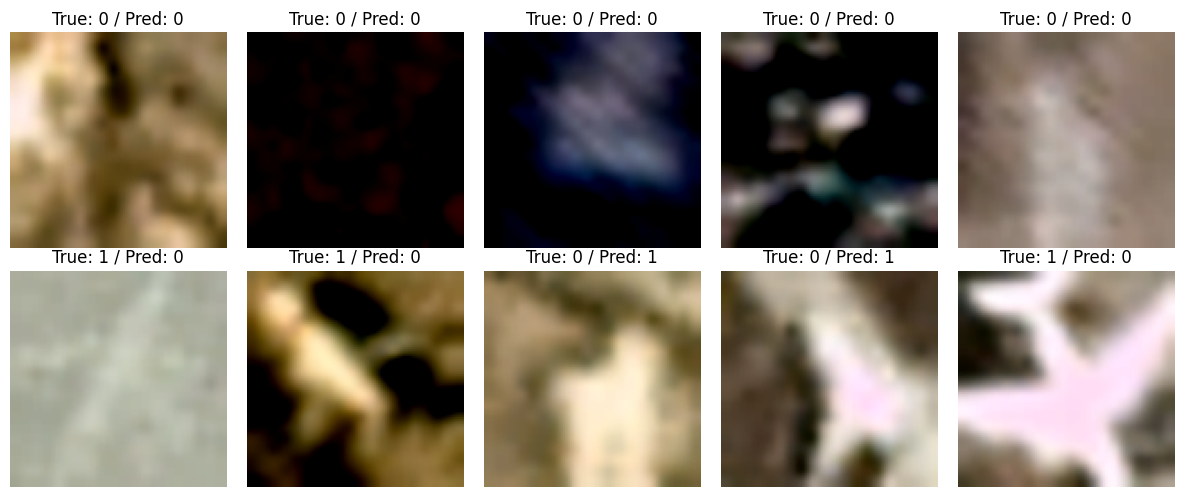

In [13]:
IMG_SIZE = 96  # MobileNetV2 input size

def generate_partial_planes_mobilenet(plane_paths, num_samples, zoom_range=(0.6, 0.9)):
    partial_images = []
    labels = []

    selected = random.sample(plane_paths, num_samples)

    for path in selected:
        img = Image.open(path).convert("RGB")
        img_np = np.array(img)
        h, w = img_np.shape[:2]

        scale = random.uniform(*zoom_range)
        new_h, new_w = int(h * scale), int(w * scale)

        x = random.randint(0, h - new_h)
        y = random.randint(0, w - new_w)

        cropped = img_np[x:x+new_h, y:y+new_w]
        resized = Image.fromarray(cropped).resize((IMG_SIZE, IMG_SIZE))
        processed = preprocess_input(np.array(resized))  # MobileNetV2-specific
        partial_images.append(processed)
        labels.append(1)  # still a plane

    return partial_images, labels



# Get only the plane images from the training set
train_plane_paths = [p for p, y in zip(train_paths, y_train) if y == 1]

# Generate 1000 partial planes
partial_imgs_mnet, partial_labels_mnet = generate_partial_planes_mobilenet(train_plane_paths, 1000)



class MixedImageGeneratorMobileNet(Sequence):
    def __init__(self, file_paths, file_labels, in_memory_images, in_memory_labels, batch_size=32, shuffle=True):
        self.file_paths = file_paths
        self.file_labels = file_labels
        self.in_memory_images = in_memory_images
        self.in_memory_labels = in_memory_labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil((len(self.file_paths) + len(self.in_memory_images)) / self.batch_size))

    def __getitem__(self, idx):
        combined = list(zip(self.file_paths, self.file_labels)) + list(zip(self.in_memory_images, self.in_memory_labels))
        if self.shuffle:
            random.shuffle(combined)

        batch = combined[idx * self.batch_size:(idx + 1) * self.batch_size]

        images = []
        labels = []

        for item in batch:
            if isinstance(item[0], str):  # it's a path
                img = Image.open(item[0]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
                img = preprocess_input(np.array(img))
            else:
                img = item[0]  # already preprocessed array
            images.append(img)
            labels.append(item[1])

        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        pass

train_gen_3b = MixedImageGeneratorMobileNet(
    train_paths, y_train,
    in_memory_images=partial_imgs_mnet,
    in_memory_labels=partial_labels_mnet,
    batch_size=32
)

test_gen_3b = PretrainedImageGenerator(test_paths, y_test, shuffle=False)

base_model_3b = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model_3b.trainable = False  # freeze pretrained layers

# Add a fresh classification head
x = base_model_3b.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

# Define a new model object (clean version of model_3b)
model_3b = Model(inputs=base_model_3b.input, outputs=output)

# Compile
model_3b.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_3b = model_3b.fit(
    train_gen_3b,
    validation_data=test_gen_3b,
    epochs=15,
    class_weight=class_weights_dict
)


# Evaluate
plot_training_history(history_3b, model_name='model_3b')

y_true, y_pred, test_images = get_predictions(model_3b, test_gen_3b, total_samples=len(y_test))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Plane", "Plane"]))

plot_confusion(y_true, y_pred, model_name="model_3b")
visualize_predictions(test_images, y_true, y_pred, num=5)



### Remarks Model 3b
Once again we see that adding the augmentation of partial planes to the training data, gives a better recall and ensures less real planes are misidentified, at the cost of precision.

## Overall results and conclusions

In the table below the classification report summary is shown per model, focussing on plane classification.

| Model | Precision (Plane) | Recall (Plane) | F1-Score (Plane) | Accuracy |
|:-----:|:-----------------:|:--------------:|:----------------:|:--------:|
|  1    |       0.94        |     0.97       |      0.95        |  0.98    |
|  2    |       0.97        |     0.90       |      0.94        |  0.97    |
|  2b   |       0.91        |     0.98       |      0.94        |  0.97    |
|  3    |       0.93        |     0.90       |      0.92        |  0.96    |
|  3b   |       0.89        |     0.95       |      0.92        |  0.96    |

It is worth noting that after having run the entire code multiple times, the results seem highly variable still. This is due to the inherent stochastic nature of CNNs. What I've consistently observed over several simulations is the following.

- In both cases, the recall is better when the model uses partial plane data to train, and this is always at the cost of precision, allowing for more false alarms. Overall accuracy is not greatly affected by this method.
- The pretrained models do well at the 1st epoch, but do not reach the same final accuracy, and take significantly longer to train. Bottom line: not worth the effort in this case, as the other CNNs do fine.

Overall model 1 seems to consistently have high accuracy, and a default high recall, which aligns with our calls. If we want to prioritize recall at the expense of precision, it may make sense to augment model 1 to get model 1b, in the same way we did before, by training on zoomed-in images of planes.

In [14]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 18, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,157 (660.77 KB)

 Trainable params: 56,385 (220.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 112,772 (440.52 KB)

None


## Future work
Due to high variability in the results, it makes sense to perform cross validation. This will also allow for stronger conclusions on the best model for this problem. However, the CNNs presented here all do very well already, and offer scalable solutions to plane identification from satellite imagery.

# By Noah Knijff 2025
https://github.com/noahknijff